Importing libraries

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv('ai4i2020.csv')

In [63]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

Text(0.5, 1.0, 'Machine Failure Distribution by Product Type')

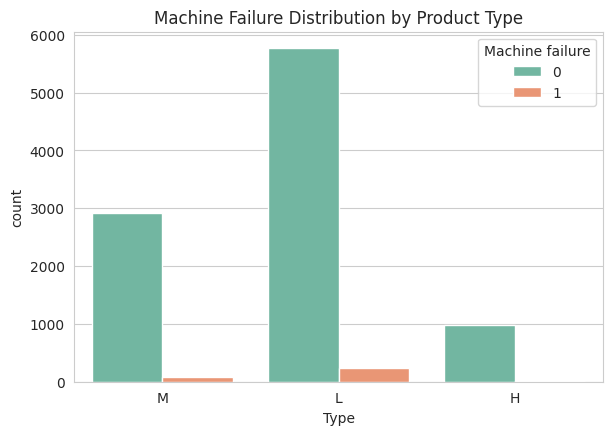

In [65]:
sns.set_style("whitegrid")

# 1. Categorical Data Analysis (FIXED - No warnings)
plt.figure(figsize=(15, 10))

# Plot 1: Countplot (already correct)
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='Type', hue='Machine failure', palette='Set2')
plt.title('Machine Failure Distribution by Product Type')

Text(0, 0.5, 'Failure Rate')

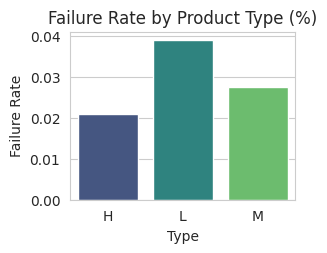

In [ ]:
# Plot 2: Barplot - FIXED
plt.subplot(2, 2, 2)
failure_by_type = df.groupby('Type')['Machine failure'].mean().reset_index()
sns.barplot(data=failure_by_type, x='Type', y='Machine failure',
            hue='Type', palette='viridis', legend=False)  # Added hue and legend=False
plt.title('Failure Rate by Product Type (%)')
plt.ylabel('Failure Rate')

Text(0.5, 0, 'Failure Count')

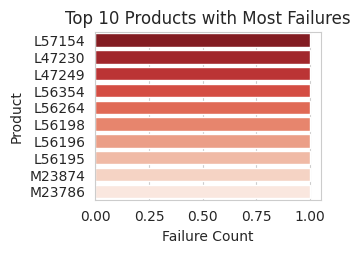

In [ ]:
# Plot 3: Top products - FIXED
plt.subplot(2, 2, 3)
top_products = df[df['Machine failure'] == 1]['Product ID'].value_counts().head(10)
top_products_df = pd.DataFrame({
    'Product': top_products.index,
    'Count': top_products.values
})
sns.barplot(data=top_products_df, x='Count', y='Product',
            hue='Product', palette='Reds_r', legend=False)  # Added hue and legend=False
plt.title('Top 10 Products with Most Failures')
plt.xlabel('Failure Count')

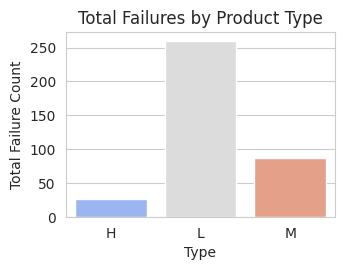

In [ ]:
# Plot 4: Total failures by type - FIXED
plt.subplot(2, 2, 4)
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_by_type = df.groupby('Type')[failure_types].sum().sum(axis=1)
failure_by_type_df = failure_by_type.reset_index()
failure_by_type_df.columns = ['Type', 'Total_Failures']
sns.barplot(data=failure_by_type_df, x='Type', y='Total_Failures',
            hue='Type', palette='coolwarm', legend=False)  # Added hue and legend=False
plt.title('Total Failures by Product Type')
plt.ylabel('Total Failure Count')

plt.tight_layout()
plt.show()

Creating continuous variable plots...


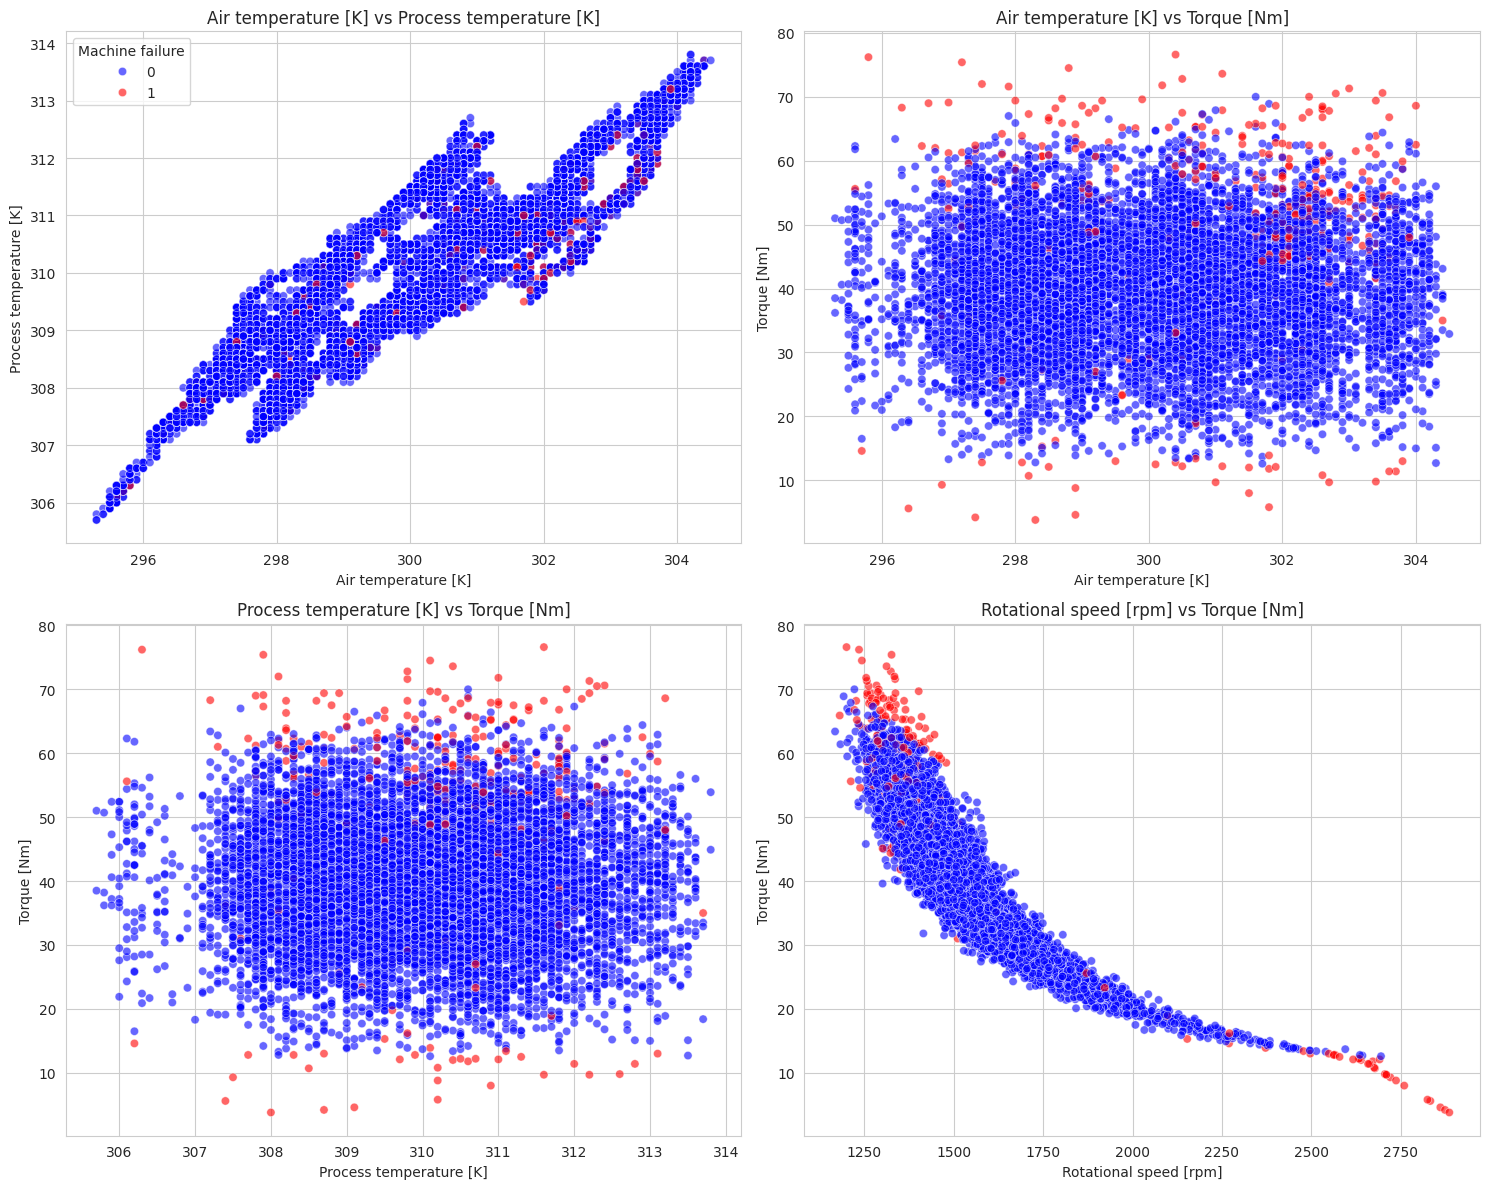

In [ ]:
# 2. Continuous Variables Analysis
print("Creating continuous variable plots...")

# Scatter plots for continuous variables
continuous_pairs = [
    ('Air temperature [K]', 'Process temperature [K]'),
    ('Air temperature [K]', 'Torque [Nm]'),
    ('Process temperature [K]', 'Torque [Nm]'),
    ('Rotational speed [rpm]', 'Torque [Nm]')
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (x_var, y_var) in enumerate(continuous_pairs):
    sns.scatterplot(data=df, x=x_var, y=y_var, hue='Machine failure',
                   palette={0: 'blue', 1: 'red'}, alpha=0.6, ax=axes[idx])
    axes[idx].set_title(f'{x_var} vs {y_var}')
    if idx > 0:  # Only show legend on first plot to avoid repetition
        axes[idx].get_legend().remove()

plt.tight_layout()
plt.show()


Creating distribution plots...


Text(0.5, 1.0, 'Rotational Speed Distribution by Failure')

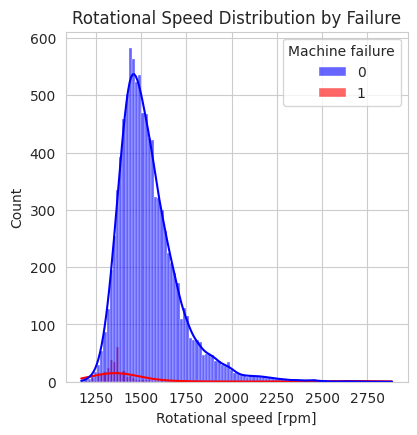

In [ ]:
# 3. Distribution Analysis (FIXED - No warnings)
print("Creating distribution plots...")
plt.figure(figsize=(15, 10))

# Plot 1: Rotational speed distribution
plt.subplot(2, 3, 1)
sns.histplot(data=df, x='Rotational speed [rpm]', hue='Machine failure',
             kde=True, alpha=0.6, palette={0: 'blue', 1: 'red'})
plt.title('Rotational Speed Distribution by Failure')

Text(0.5, 1.0, 'Tool Wear Distribution by Failure')

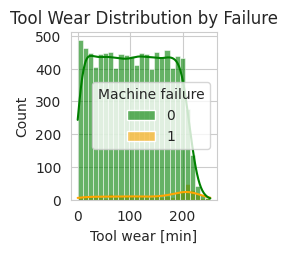

In [ ]:
plt.subplot(2, 3, 2)
sns.histplot(data=df, x='Tool wear [min]', hue='Machine failure',
             kde=True, alpha=0.6, palette={0: 'green', 1: 'orange'})
plt.title('Tool Wear Distribution by Failure')

/tmp/ipython-input-501431318.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Machine failure', y='Tool wear [min]', palette='Set2')


Text(0.5, 1.0, 'Tool Wear by Failure Status')

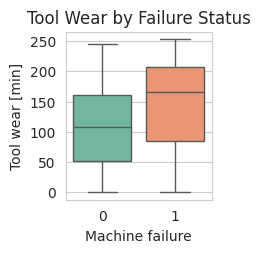

In [ ]:
# Plot 3: Tool wear boxplot
plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='Machine failure', y='Tool wear [min]', palette='Set2')
plt.title('Tool Wear by Failure Status')


/tmp/ipython-input-3554641728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Machine failure', y='Rotational speed [rpm]', palette='pastel')


Text(0.5, 1.0, 'Rotational Speed by Failure Status')

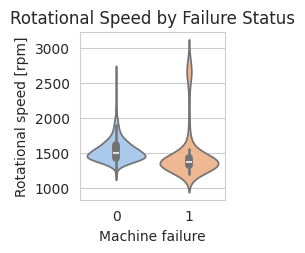

In [ ]:
# Plot 4: Rotational speed violin plot
plt.subplot(2, 3, 4)
sns.violinplot(data=df, x='Machine failure', y='Rotational speed [rpm]', palette='pastel')
plt.title('Rotational Speed by Failure Status')


([0, 1, 2, 3, 4],
 [Text(0, 0, 'TWF'),
  Text(1, 0, 'HDF'),
  Text(2, 0, 'PWF'),
  Text(3, 0, 'OSF'),
  Text(4, 0, 'RNF')])

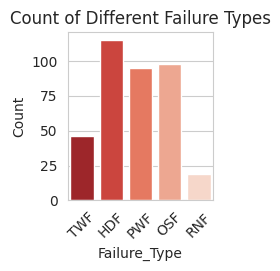

In [ ]:
# Plot 5: Failure types - FIXED
plt.subplot(2, 3, 5)
failure_counts = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum().reset_index()
failure_counts.columns = ['Failure_Type', 'Count']
sns.barplot(data=failure_counts, x='Failure_Type', y='Count',
            hue='Failure_Type', palette='Reds_r', legend=False)  # Added hue and legend=False
plt.title('Count of Different Failure Types')
plt.xticks(rotation=45)


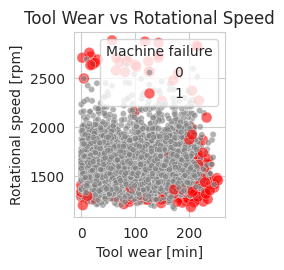

In [ ]:
# Plot 6: Scatter with size encoding
plt.subplot(2, 3, 6)
sns.scatterplot(data=df, x='Tool wear [min]', y='Rotational speed [rpm]',
                hue='Machine failure', size='Machine failure',
                sizes={0: 20, 1: 60}, palette={0: 'gray', 1: 'red'}, alpha=0.6)
plt.title('Tool Wear vs Rotational Speed')

plt.tight_layout()
plt.show()

Creating correlation heatmap...


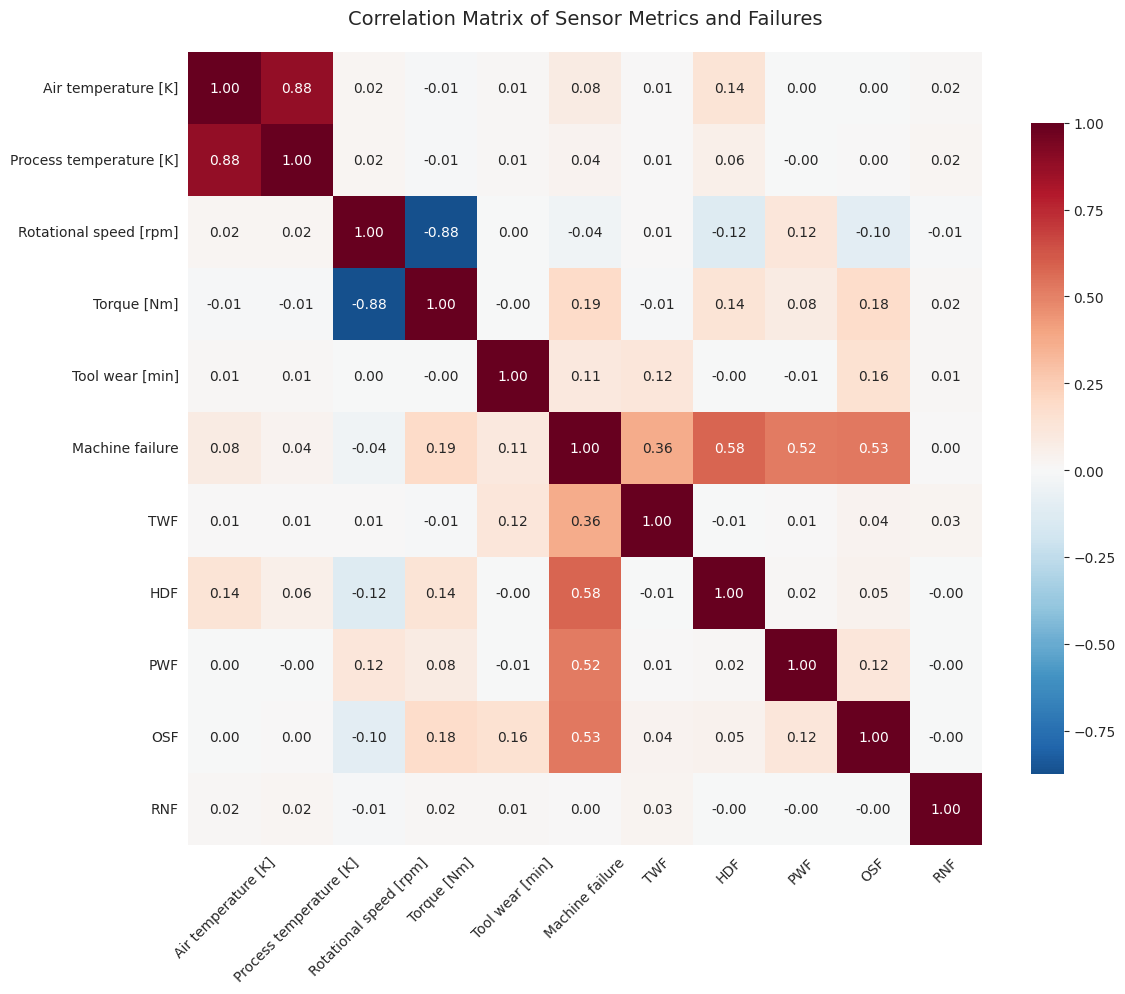

In [ ]:
# 4. Correlation Heatmap
print("Creating correlation heatmap...")
numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='RdBu_r',
            center=0,
            fmt='.2f',
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Sensor Metrics and Failures', fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Creating pairplot...


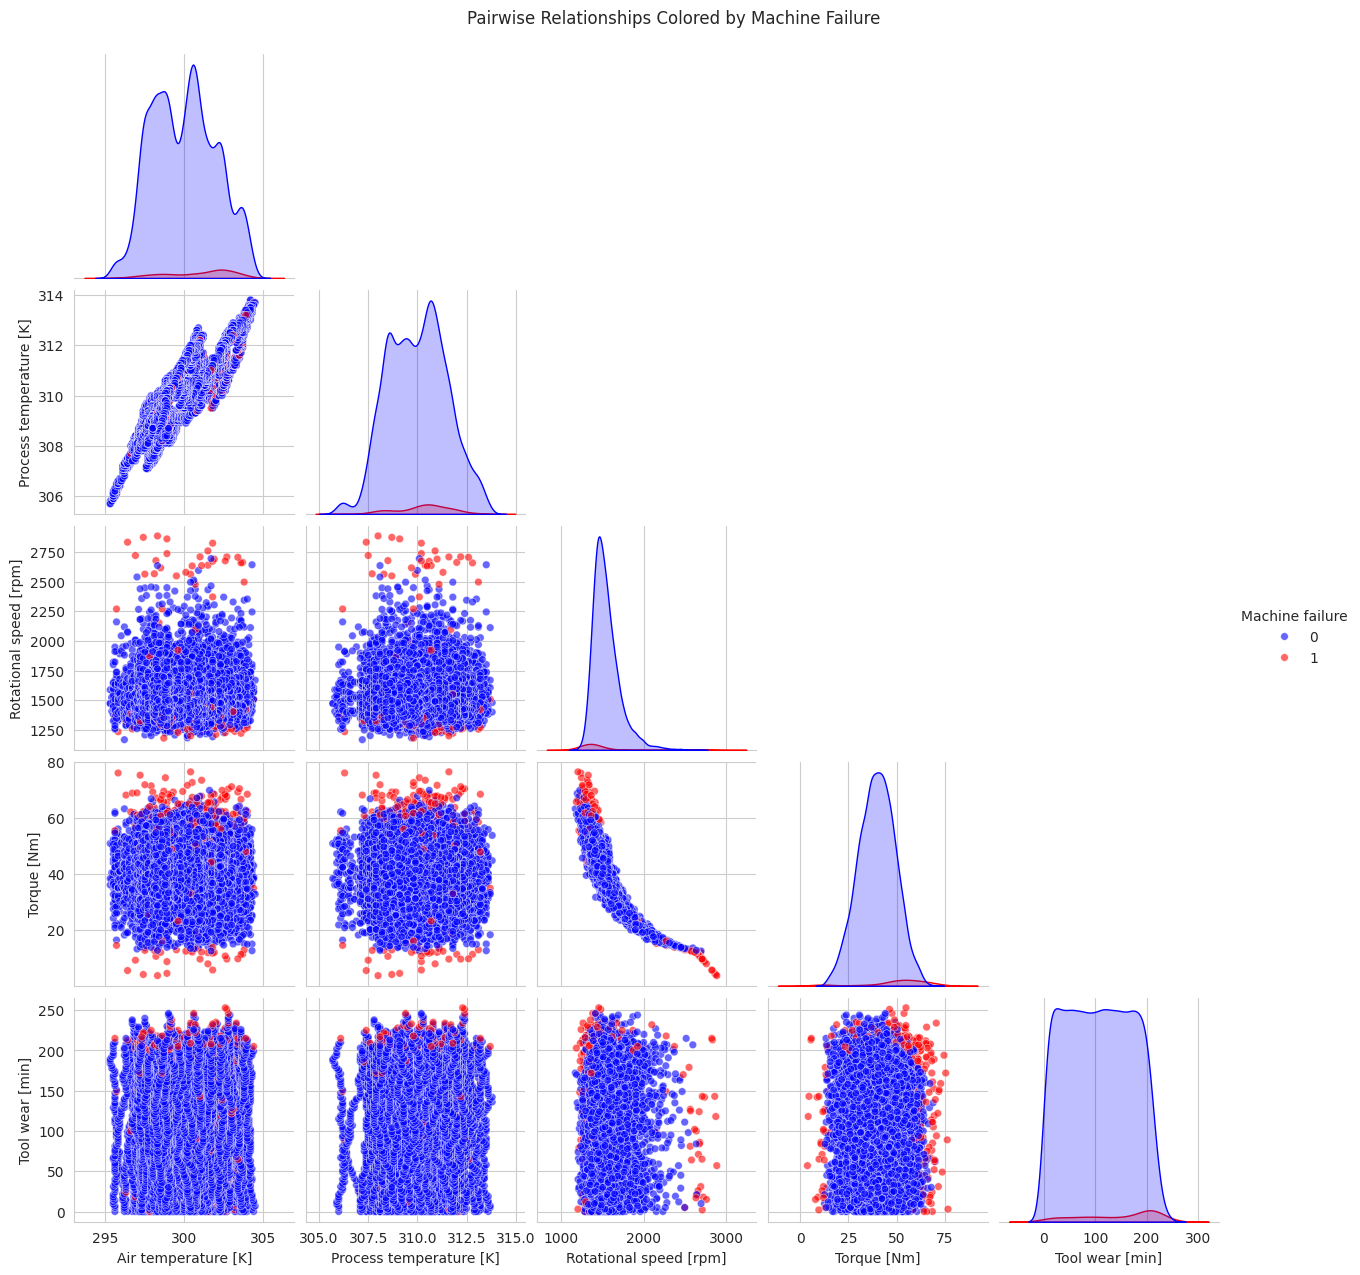

In [ ]:
# 5. Advanced Analysis - Pairplot
print("Creating pairplot...")
key_columns = ['Air temperature [K]', 'Process temperature [K]',
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
               'Machine failure']
# Convert to categorical for better coloring
pairplot_df = df[key_columns].copy()
pairplot_df['Machine failure'] = pairplot_df['Machine failure'].astype('category')

sns.pairplot(pairplot_df,
             hue='Machine failure',
             diag_kind='kde',
             palette={0: 'blue', 1: 'red'},
             plot_kws={'alpha': 0.6, 's': 30},
             corner=True)
plt.suptitle('Pairwise Relationships Colored by Machine Failure', y=1.02)
plt.show()


##Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [73]:
def clean_column_names(df):
    """Remove invalid characters from column names"""
    df_clean = df.copy()
    df_clean.columns = [col.replace('[', '').replace(']', '').replace('<', '')
                       for col in df_clean.columns]
    return df_clean

# Apply to your original DataFrame first
df = clean_column_names(df)

In [79]:
df.head()

,UDI,Product ID,Type,Air temperature K,Process temperature K,Rotational speed rpm,Torque Nm,Tool wear min,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [82]:
def prepare_features_and_target(df):
    """
    Features: Sensor data and operational parameters
    Target: Machine failure (binary)
    """

    # FEATURES - What causes failures
    feature_columns = [
        'Air temperature K', 'Process temperature K',
        'Rotational speed rpm', 'Torque Nm',
        'Tool wear min', 'Type'
    ]

    X = df[feature_columns].copy()

    # Feature engineering
    X['temp_difference'] = X['Process temperature K'] - X['Air temperature K']
    X['power_estimate'] = (X['Torque Nm'] * X['Rotational speed rpm']) / 9549
    X['wear_rate'] = X['Tool wear min'] / (X['Rotational speed rpm'] + 1)

    # Encode categorical
    le = LabelEncoder()
    X['Type_encoded'] = le.fit_transform(X['Type'])

    # Drop original categorical column
    X = X.drop(['Type'], axis=1)

    # TARGET - What we want to predict
    y = df['Machine failure']

    # Verify target is binary
    print("Target verification:")
    print(f"Unique values: {y.unique()}")
    print(f"Value counts:\n{y.value_counts()}")

    return X, y

##Model Development

In [ ]:
!pip install xgboost

In [84]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [85]:
X, y = prepare_features_and_target(df)

Target verification:
Unique values: [0 1]
Value counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [86]:
y

,Machine failure
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,0
9997,0
9998,0


In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [72]:
X_train

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],temp_difference,power_estimate,wear_rate,Type_encoded
7963,301.0,312.2,1510,39.9,61,11.2,6.309456,0.040371,1
5117,304.1,313.6,1611,31.4,144,9.5,5.297455,0.089330,1
537,297.4,309.3,1516,43.0,83,11.9,6.826683,0.054713,0
8209,299.3,310.8,1391,46.9,21,11.5,6.831909,0.015086,1
6647,301.5,310.5,1927,22.4,149,9.0,4.520348,0.077282,1
...,...,...,...,...,...,...,...,...,...
6701,301.6,310.9,1623,34.1,56,9.3,5.795822,0.034483,1
6383,300.2,309.7,1483,43.8,108,9.5,6.802325,0.072776,0
6500,300.9,310.0,1416,46.6,201,9.1,6.910210,0.141849,2
448,297.5,308.6,1552,44.9,77,11.1,7.297602,0.049581,1


In [88]:
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [89]:
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9843333333333333
